Assignment Task:  
Your task is to perform a multiple linear regression analysis to predict the price of Toyota corolla based on the given attributes.  
Dataset Description:  
The dataset consists of the following variables:  
Age: Age in years  
KM: Accumulated Kilometers on  odometer  
FuelType: Fuel Type (Petrol, Diesel, CNG)  
HP: Horse Power  
Automatic: Automatic ( (Yes=1, No=0)
CC: Cylinder Volume in cubic centimeters  
Doors: Number of doors  
Weight: Weight in Kilograms  
Quarterly_Tax:   
Price: Offer Price in EUROs  


Tasks:  
1.Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df=pd.read_csv('ToyotaCorolla - MLR.csv')
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


In [12]:
df.shape

(1436, 11)

In [13]:
df.size

15796

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [15]:
df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


In [16]:
df.duplicated().sum()

np.int64(1)

In [17]:
df.drop_duplicates(inplace=True)


In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.columns

Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='object')

In [20]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.0,1435.000000,1435.000000
mean,10720.915679,55.980488,68571.782578,101.491986,0.055749,1576.560976,4.032753,4.0,5.026481,1072.287108
std,3608.732978,18.563312,37491.094553,14.981408,0.229517,424.387533,0.952667,0.0,0.188575,52.251882
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.000000,2.000000,4.0,3.000000,1000.000000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.000000,3.000000,4.0,5.000000,1040.000000
50%,9900.000000,61.000000,63451.000000,110.000000,0.000000,1600.000000,4.000000,4.0,5.000000,1070.000000
75%,11950.000000,70.000000,87041.500000,110.000000,0.000000,1600.000000,5.000000,4.0,5.000000,1085.000000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.000000,5.000000,4.0,6.000000,1615.000000


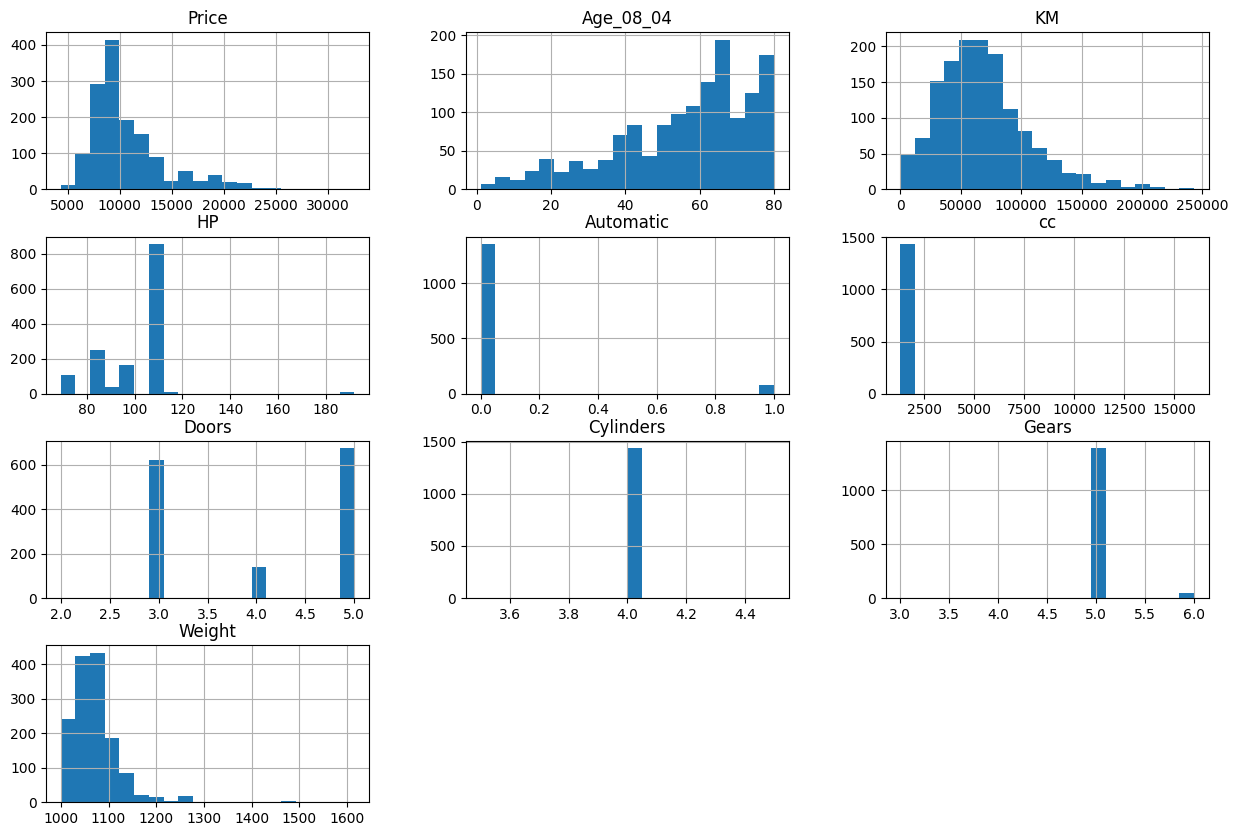

In [21]:
#visualization
df.hist(figsize=(15,10), bins=20)
plt.show()

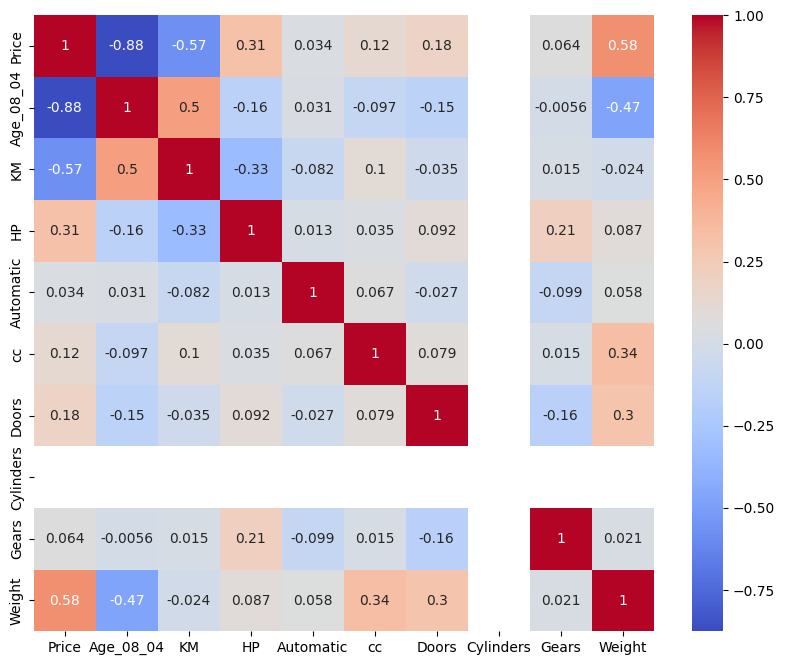

In [22]:
#corelation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

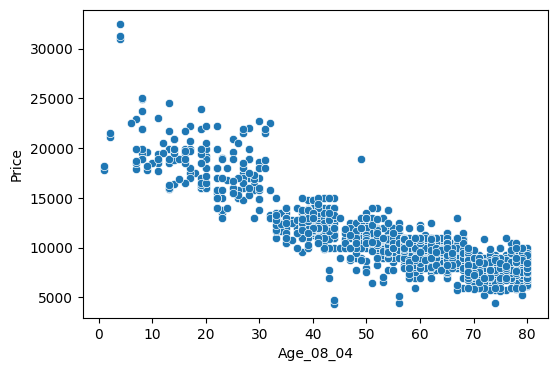

In [23]:
#scatter plot(Age v/s Price)
plt.figure(figsize=(6,4))
sns.scatterplot(x='Age_08_04', y='Price', data=df)
plt.show()

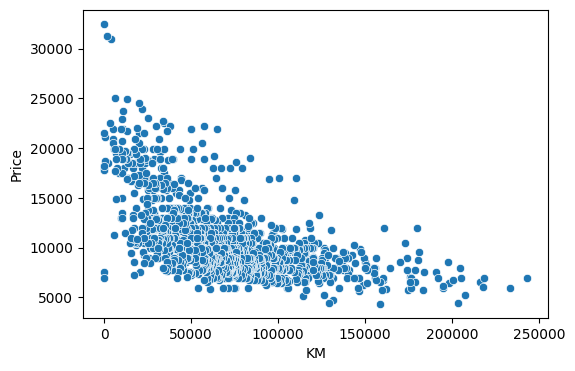

In [24]:
#scatter(km vs price)
plt.figure(figsize=(6,4))
sns.scatterplot(x='KM', y='Price', data=df)
plt.show()

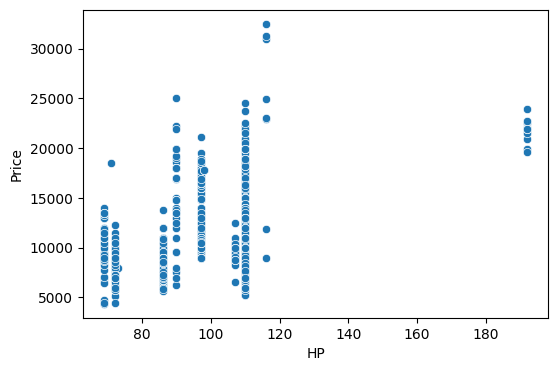

In [25]:
#hp vs price
plt.figure(figsize=(6,4))
sns.scatterplot(x='HP', y='Price', data=df)
plt.show()

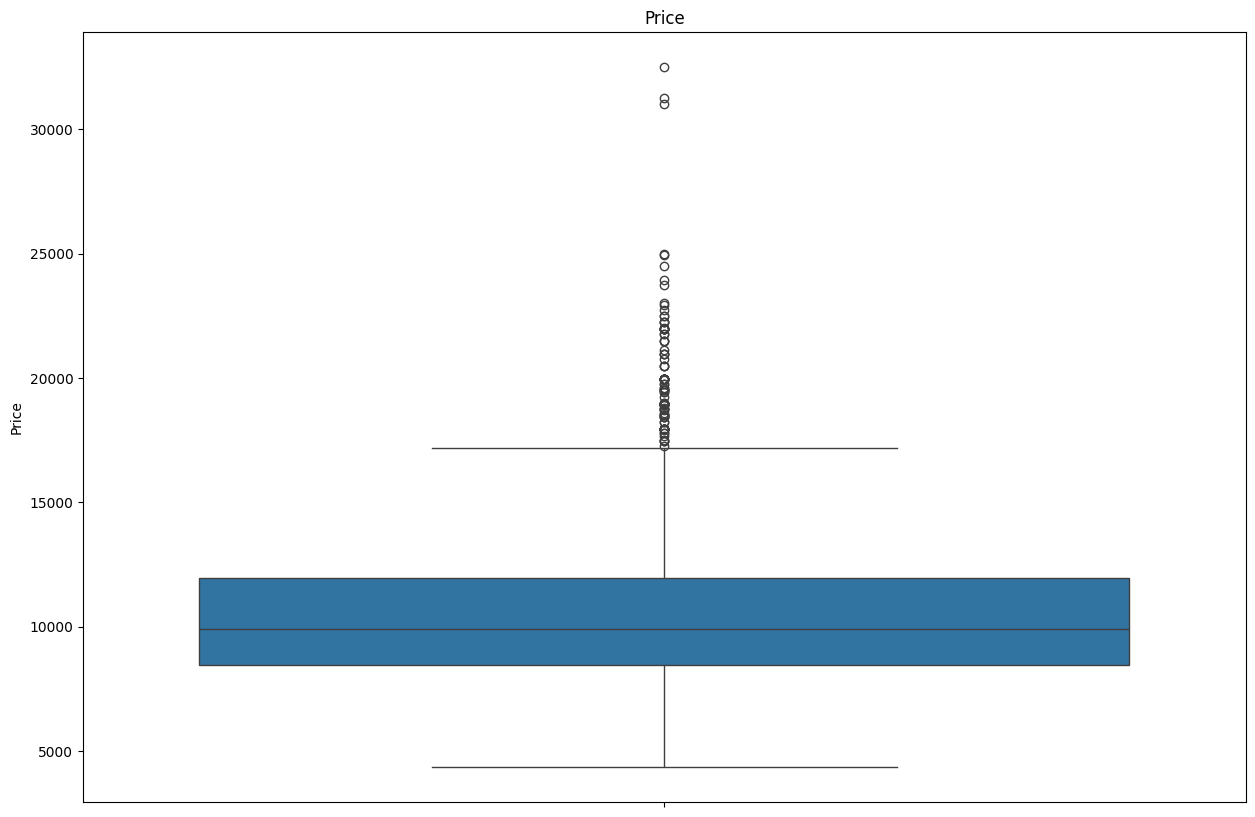

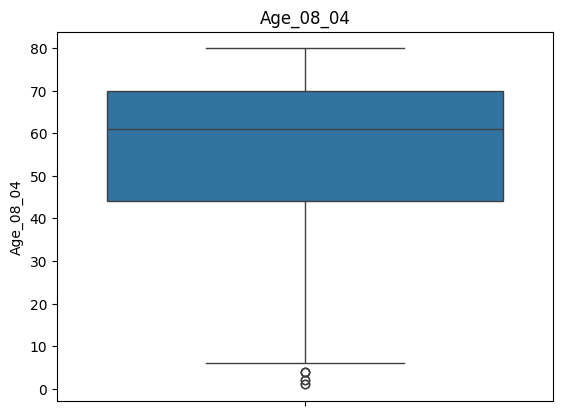

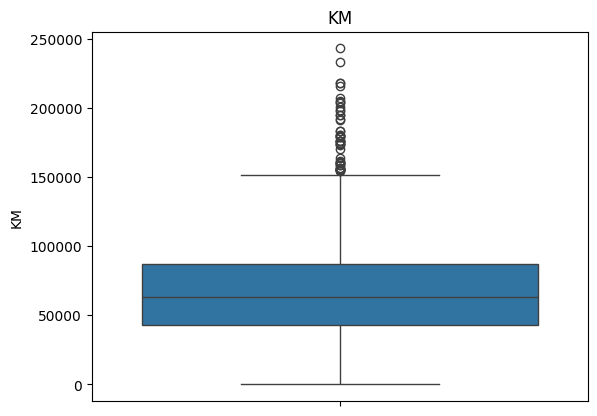

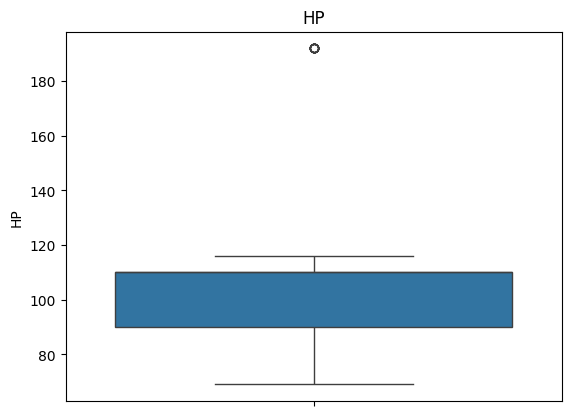

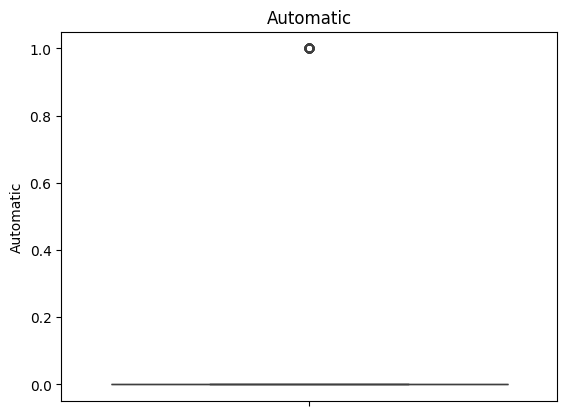

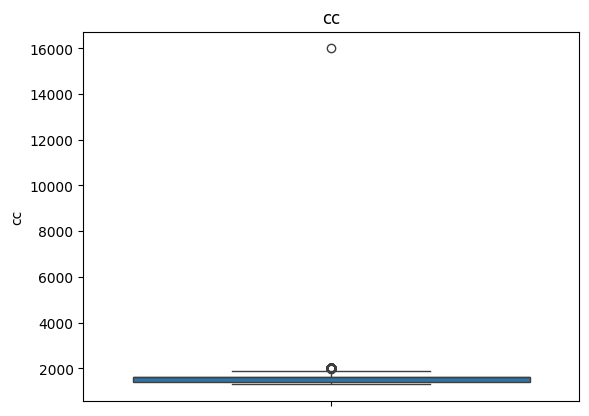

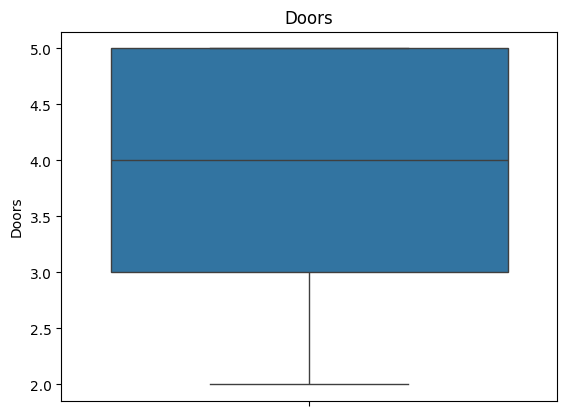

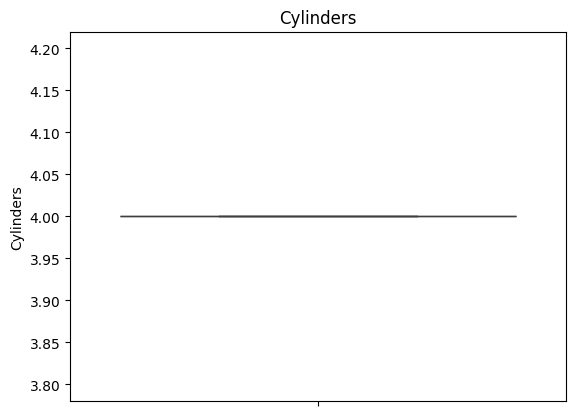

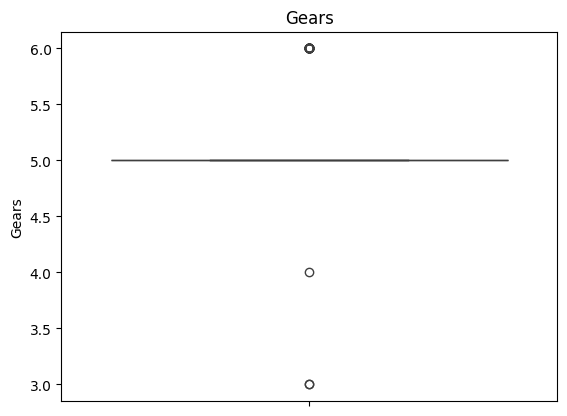

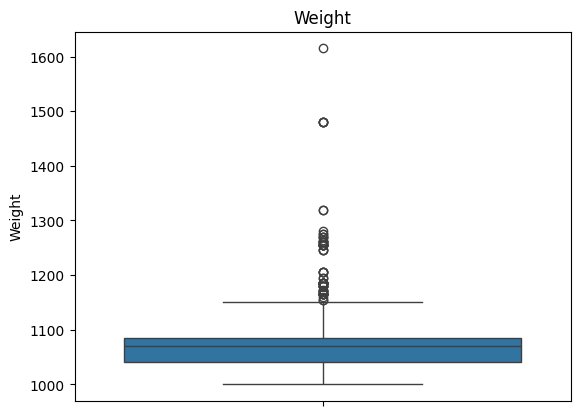

In [26]:
#boxplot for outlier detection
plt.figure(figsize=(15,10))
for col in df.select_dtypes(include='number').columns:
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.show()

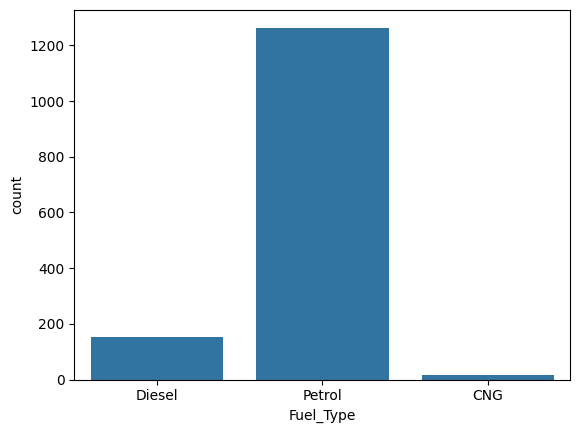

In [27]:
#fuel type distribution
sns.countplot(x='Fuel_Type', data=df)
plt.show()

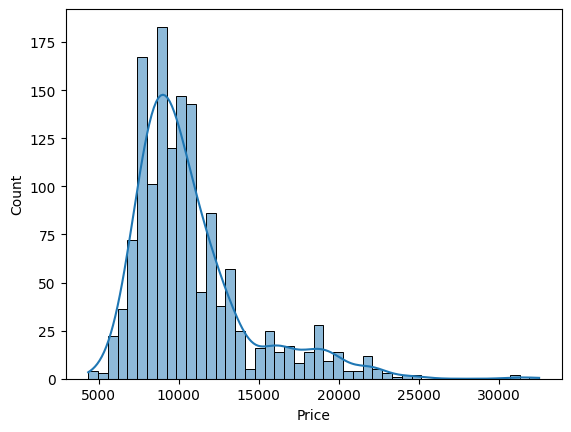

In [28]:
#price distribution
sns.histplot(df['Price'], kde=True)
plt.show()

Pre processing the data to apply the MLR


In [29]:
#convert fuel type into numerical
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])

In [30]:
df.dtypes

,0
Price,int64
Age_08_04,int64
KM,int64
Fuel_Type,int64
HP,int64
Automatic,int64
cc,int64
Doors,int64
Cylinders,int64
Gears,int64


In [31]:
#separate features and target values
X = df[['Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc', 'Doors', 'Weight']]
y = df['Price']

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (1148, 8)
X_test shape: (287, 8)
y_train shape: (1148,)
y_test shape: (287,)


In [34]:
X.head()

,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Weight
0,23,46986,1,90,0,2000,3,1165
1,23,72937,1,90,0,2000,3,1165
2,24,41711,1,90,0,2000,3,1165
3,26,48000,1,90,0,2000,3,1165
4,30,38500,1,90,0,2000,3,1170


In [35]:
y.head()

,Price
0,13500
1,13750
2,13950
3,14950
4,13750


2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [38]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1148, 8)
X_test shape: (287, 8)
y_train shape: (1148,)
y_test shape: (287,)


3.Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models.

In [39]:
from sklearn.linear_model import LinearRegression
#Model 1
model1 = LinearRegression()
model1.fit(X_train, y_train)
print("Intercept:", model1.intercept_)

Intercept: -10424.59355372404


In [40]:
#display coeffient
coefficients1 = pd.DataFrame({'Feature': X_train.columns,'Coefficient': model1.coef_})
coefficients1

,Feature,Coefficient
0,Age_08_04,-121.832763
1,KM,-0.016690
2,Fuel_Type,844.932280
3,HP,24.899596
4,Automatic,346.229576
5,cc,-0.097253
6,Doors,-77.417312
7,Weight,23.736494


In [41]:
#Model 2
X2 = df[['Age_08_04','KM','HP','Weight']]
y2 = df['Price']

In [43]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2,test_size=0.2,random_state=42)

In [44]:
model2 = LinearRegression()
model2.fit(X2_train, y2_train)
print("Intercept:", model2.intercept_)

LinearRegression()

In [45]:
coefficients2 = pd.DataFrame({'Feature': X2_train.columns,'Coefficient': model2.coef_})
coefficients2

,Feature,Coefficient
0,Age_08_04,-120.619071
1,KM,-0.020074
2,HP,31.478589
3,Weight,19.847999


In [46]:
import warnings
warnings.filterwarnings('ignore')

#model 3
X3 = df[['Age_08_04','KM','Fuel_Type','Weight']]
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y,test_size=0.2,random_state=42)
model3 = LinearRegression()
model3.fit(X3_train, y3_train)
print("Intercept:", model3.intercept_)

Intercept: -12093.516494297153


In [47]:
coefficients3 = pd.DataFrame({'Feature': X3_train.columns,'Coefficient': model3.coef_})
coefficients3

,Feature,Coefficient
0,Age_08_04,-120.049149
1,KM,-0.018166
2,Fuel_Type,1424.547887
3,Weight,26.224888


After displaying the coefficient table for each model, you can write:  
A positive coefficient indicates that as the feature increases, the predicted Price also increases, assuming all other variables remain constant.   
A negative coefficient indicates that as the feature increases, the predicted Price decreases, assuming all other variables remain constant.   
The intercept represents the predicted price when all independent variables are zero.

4.Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.

In [48]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

In [49]:
#model 1
y_pred1 = model1.predict(X_test)
mae1 = mean_absolute_error(y_test, y_pred1)
mse1 = mean_squared_error(y_test, y_pred1)
rmse1 = np.sqrt(mse1)
r2_1 = r2_score(y_test, y_pred1)
print("Model 1 Performance")
print("MAE :", mae1)
print("MSE :", mse1)
print("RMSE:", rmse1)
print("R² Score:", r2_1)

Model 1 Performance
MAE : 977.6598095782554
MSE : 2038244.4798652253
RMSE: 1427.6709984675128
R² Score: 0.8301057136951332


In [51]:
#model 2
y_pred2 = model2.predict(X2_test)
mae2 = mean_absolute_error(y2_test, y_pred2)
mse2 = mean_squared_error(y2_test, y_pred2)
rmse2 = np.sqrt(mse2)
r2_2 = r2_score(y2_test, y_pred2)
print("Model 2 Performance")
print("MAE :", mae2)
print("MSE :", mse2)
print("RMSE:", rmse2)
print("R² Score:", r2_2)

Model 2 Performance
MAE : 987.225283393743
MSE : 1934478.8193824275
RMSE: 1390.8554272038584
R² Score: 0.8387549179514566


In [50]:
#model 3
y_pred3 = model3.predict(X3_test)
mae3 = mean_absolute_error(y3_test, y_pred3)
mse3 = mean_squared_error(y3_test, y_pred3)
rmse3 = np.sqrt(mse3)
r2_3 = r2_score(y3_test, y_pred3)
print("Model 3 Performance")
print("MAE :", mae3)
print("MSE :", mse3)
print("RMSE:", rmse3)
print("R² Score:", r2_3)

Model 3 Performance
MAE : 947.7203288038445
MSE : 2150522.2350277957
RMSE: 1466.4658997152972
R² Score: 0.8207469987471998


Interpretation:  
After viewing the table, you can write:    
MAE (Mean Absolute Error): Lower values indicate better prediction accuracy.     
MSE (Mean Squared Error): Lower values indicate fewer prediction errors.   
RMSE (Root Mean Squared Error): Lower values indicate the model's predictions are closer to the actual prices.    
R² Score: Values closer to 1 indicate a better fit and stronger predictive performance.  
Finally, identify the model with the highest R² score and the lowest MAE, MSE, and RMSE. That model can be considered the best-performing Multiple Linear Regression model for predicting the Toyota Corolla price.

5.Apply Lasso and Ridge methods on the model.

In [52]:
from sklearn.linear_model import Ridge, Lasso

In [53]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

Ridge()

In [54]:
y_pred_ridge = ridge_model.predict(X_test)

In [55]:
#Evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, y_pred_ridge)
print("Ridge Regression Performance")
print("MAE :", ridge_mae)
print("MSE :", ridge_mse)
print("RMSE:", ridge_rmse)
print("R2 Score:", ridge_r2)

Ridge Regression Performance
MAE : 977.4714039580069
MSE : 2035947.874620509
RMSE: 1426.866452973266
R2 Score: 0.8302971431889106


In [56]:
#Display ridge coeffiecient
ridge_coefficients = pd.DataFrame({'Feature': X_train.columns,'Coefficient': ridge_model.coef_})
ridge_coefficients

,Feature,Coefficient
0,Age_08_04,-121.814420
1,KM,-0.016738
2,Fuel_Type,832.218352
3,HP,25.003665
4,Automatic,342.118589
5,cc,-0.097660
6,Doors,-76.806333
7,Weight,23.686307


In [57]:
#Lassso Regression Model
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)

Lasso()

In [58]:
#pridict using lasso model
y_pred_lasso = lasso_model.predict(X_test)

In [59]:
#evaluate using lasso model
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
lasso_mse = mean_squared_error(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, y_pred_lasso)
print("Lasso Regression Performance")
print("MAE :", lasso_mae)
print("MSE :", lasso_mse)
print("RMSE:", lasso_rmse)
print("R2 Score:", lasso_r2)

Lasso Regression Performance
MAE : 977.1621394914979
MSE : 2034355.992684091
RMSE: 1426.3085194599698
R2 Score: 0.8304298317099104


In [60]:
#Lsso Coefficient
lasso_coefficients = pd.DataFrame({'Feature': X_train.columns,'Coefficient': lasso_model.coef_})
lasso_coefficients

,Feature,Coefficient
0,Age_08_04,-121.780280
1,KM,-0.016767
2,Fuel_Type,828.515338
3,HP,25.018347
4,Automatic,328.196765
5,cc,-0.097209
6,Doors,-75.616150
7,Weight,23.672972


In [62]:
#compare MLR, Ridge and Lasso
comparison = pd.DataFrame({'Model': ['Multiple Linear Regression', 'Ridge Regression', 'Lasso Regression'],'MAE': [mae1, ridge_mae, lasso_mae],'MSE': [mse1, ridge_mse, lasso_mse],'RMSE': [rmse1, ridge_rmse, lasso_rmse],'R2 Score': [r2_1, ridge_r2, lasso_r2]})
comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Multiple Linear Regression,977.659810,2.038244e+06,1427.670998,0.830106
1,Ridge Regression,977.471404,2.035948e+06,1426.866453,0.830297
2,Lasso Regression,977.162139,2.034356e+06,1426.308519,0.830430


Interview Questions:    
1.What is Normalization & Standardization and how is it helpful?   
Normalization:   
Normalization is a data preprocessing technique that rescales the values of numerical features to a fixed range, typically 0 to 1.​    
Standardization:
Standardization is a preprocessing technique that transforms data so that it has a mean of 0 and a standard deviation of 1.   
How are they helpful:   
They ensure that all features contribute equally to the model.   
They improve the accuracy and efficiency of machine learning algorithms.  
They reduce the effect of differences in feature scales.  
They help optimization algorithms converge faster during model training.  
They improve the overall stability and performance of predictive models.

2.What techniques can be used to address multicollinearity in multiple linear regression?  
Answer: Multicollinearity occurs when two or more independent variables are highly correlated with each other. This makes it difficult to estimate the individual effect of each predictor on the dependent variable and can lead to unstable regression coefficients.  
Techniques to Address Multicollinearity  
1. Remove Highly Correlated Variables
Calculate the correlation matrix.
If two variables have a very high correlation (e.g., greater than 0.8 or 0.9), remove one of them.   
Example:
If Engine Size and Cylinder Volume (CC) are highly correlated, keep only one of them.    
2. Check Variance Inflation Factor (VIF)   
VIF measures how much multicollinearity exists among the independent variables.
A VIF greater than 5 or 10 indicates high multicollinearity.
3. Use Ridge Regression
Ridge    Regression uses L2 regularization.
It reduces the magnitude of regression coefficients and handles multicollinearity without removing variables.
4. Use Lasso Regression   
Lasso Regression uses L1 regularization.
It can reduce some coefficients to zero, automatically selecting the most important features.    
5. Feature Selection    
Remove variables that contribute little to the model.
Retain only the most relevant predictors based on statistical tests or domain knowledge.
6. Principal Component Analysis (PCA)    
PCA transforms correlated variables into a new set of uncorrelated variables called principal components.
These components can then be used for regression.

Ensure to properly comment your code and provide explanations for your analysis.


In [63]:
# Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
# Load the Toyota Corolla dataset
df = pd.read_csv("ToyotaCorolla - MLR.csv")

In [67]:
# Display the first five rows of the dataset
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [68]:
# Check for missing values
df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


In [69]:
# Encode the categorical variable 'FuelType'
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])

In [70]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [71]:
# Train the Multiple Linear Regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [72]:
# Predict the prices using the testing dataset
y_pred = model.predict(X_test)

In [73]:
# Evaluate the model using regression metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Include any assumptions made during the analysis and discuss their implications.           
Answer:Analysis / Explanation     
 **Exploratory Data Analysis (EDA)**
The dataset was explored using summary statistics and visualizations.   
Missing values and duplicate records were checked before model building.   
Histograms, scatter plots, boxplots, and a correlation heatmap were used to understand the distribution of variables and their relationships.   
Outliers were identified using boxplots and handled using the IQR method (if you included this step).   
**Data Preprocessing**  
The categorical variable FuelType was encoded into numerical values.   
The dataset was divided into training (80%) and testing (20%) sets.   
The data was prepared for Multiple Linear Regression.   
**Model Building**
Three Multiple Linear Regression models were built using different combinations of predictor variables.   
Ridge Regression and Lasso Regression were also applied to compare the performance with the standard Multiple Linear Regression model.   
**Model Evaluation**  
The models were evaluated using:   
Mean Absolute Error (MAE)  
Mean Squared Error (MSE)   
Root Mean Squared Error (RMSE)   
R² Score     
The model with the highest R² Score and the lowest error values was considered the best-performing model.

**Assumptions Made During the Analysis**    
The dataset is accurate and representative of Toyota Corolla car prices.    
Missing values and duplicate records were handled before model training.    
The relationship between the independent variables and the target variable (Price) is assumed to be linear.    
The observations are assumed to be independent of each other.    
The error terms are assumed to have constant variance (homoscedasticity).   
The residual errors are assumed to be approximately normally distributed.   
Multicollinearity among predictor variables was reduced by applying Ridge and Lasso Regression.   
The 80:20 train-test split provides sufficient data for both training and evaluating the model.

**Implications of These Assumptions**         
If the assumption of linearity is violated, the model may not accurately predict car prices.     
High multicollinearity can make regression coefficients unstable, which is why Ridge and Lasso Regression were applied.    
Outliers may affect the model's performance; therefore, they should be identified and handled if necessary.    
If the residuals are not normally distributed or have unequal variance, prediction accuracy may decrease.    
The evaluation metrics (MAE, MSE, RMSE, and R² Score) help determine how well the model generalizes to unseen data.